## ClusterDE for PBMC Data

This notebook gives an example of applying ClusterDE to identify significant marker genes when there are true between-cluster differences. It is based on the [PBMC example](https://github.com/SONGDONGYUAN1994/ClusterDE/blob/1601ae76af352a8663a040be4330e5537164436a/vignettes/ClusterDE-PBMC.Rmd) from the ClusterDE package documentation, which compares clusters found through a generic cell type clustering pipeline. These two clusters turn out to correspond exactly to CD14+ and Fcgr3a+ monocytes. This notebook walks through the format of the data that must be passed into ClusterDE and the interpretations of the software output.

The key hyperparameters for this workflow are listed below. `CLUSTERING_RESOLUTION` and `N_CLUSTERING_HVGS` are passed into the scanpy clustering pipeline and control how small the clusters are allowed to become and how stringent a gene filter is applied, respectively. When the clustering resolution is set very high, we risk over-clustering the data and splitting what should be one cluster into multiple. The number of highly varying genes to use in the clustering analysis also influences the results. The fewer highly varying genes are considered, the easier the comparisons are, because statistical comparison is easier when there are fewer features present. However, if it's set too small, then genes that actually discriminate between cell types might be missed. `FDR` Is a hyperparameter of cluster DE, and it controls the false discovery rate targeted by the method. This is the analog of the significance level when working with the multi-gene comparisons used by ClusterDE. The `SEED` hyperparameter makes sure that the analysis is fully reproducible, and it is good practice to include in any notebook.

### Initial Clustering

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
from clusterde_py import find_markers

CLUSTER_RESOLUTION = 0.3
N_CLUSTERING_HVGS = 2000
FDR = 0.05
SEED = 0

The original data are stored in the `scanpy.datasets.pbmc3k` data object. The blocks below perform a generic scikit-learn clustering pipeline. ClusterDE supports any kind of clustering algorithm, since the cawlibration step is agnostic to the way the clusterings are obtained. Our first block filters away the very rare cells and genes, And the second applies a log counts-per-10,000 reads transformation. The last block applies PCA and performs clustering after projecting onto the ten-dimensional subspace that explains the most variation.

In [2]:
# filter
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_counts=100)

# normalize
cdata = adata.copy()
sc.pp.normalize_total(cdata, target_sum=1e4)
sc.pp.log1p(cdata)
sc.pp.highly_variable_genes(cdata, n_top_genes=N_CLUSTERING_HVGS)

# cluster
hvg = cdata[:, cdata.var.highly_variable].copy()
sc.pp.scale(hvg, max_value=10)
sc.tl.pca(hvg, n_comps=10, svd_solver="arpack", random_state=SEED)
sc.pp.neighbors(hvg, n_neighbors=10, random_state=SEED)
sc.tl.leiden(hvg, resolution=CLUSTER_RESOLUTION, flavor="igraph", n_iterations=2, random_state=SEED)

cdata.obs["leiden"] = hvg.obs["leiden"].values
adata.obs["leiden"] = hvg.obs["leiden"].values
cdata.obs["leiden"].value_counts()

leiden
3    719
4    525
0    449
2    361
1    359
6    159
5    116
7     12
Name: count, dtype: int64

### ClusterDE Setup

The core ClusterDE method focuses on whether a pair of clusters is in fact a continuous gradient, though there are extensions that compare pairs of clusters hierarchically. We will work without these extensions, though, which requires us to isolate a pair of clusters of particular interest. For this, we will focus on the CD14+ and FCGR3A+ monocyte clusters, which can be identified through their marker genes. According to the clustering results above, these seem to be clusters 4 and 6, respectively. 

In [3]:
expr = sc.get.obs_df(cdata, keys=["CD14", "FCGR3A"])
expr["leiden"] = cdata.obs["leiden"].values
means = expr.groupby("leiden", observed=True).mean()

cd14_cluster = means["CD14"].idxmax()
cd16_cluster = means.drop(index=cd14_cluster)["FCGR3A"].idxmax()
print(f"CD14+ classical monocyte cluster: {cd14_cluster!r}")
print(f"FCGR3A+/CD16+ non-classical monocyte cluster: {cd16_cluster!r}")

GROUP1 = "CD14+ Monocytes"
GROUP2 = "FCGR3A+ Monocytes"
adata.obs["monocyte_type"] = adata.obs["leiden"].map({cd14_cluster: GROUP1, cd16_cluster: GROUP2})
adata_filtered = adata[adata.obs["monocyte_type"].notna()].copy()
adata_filtered.obs["monocyte_type"] = adata_filtered.obs["monocyte_type"].astype("category")

CD14+ classical monocyte cluster: '4'
FCGR3A+/CD16+ non-classical monocyte cluster: '6'


Next we run a standard marker gene analysis (log normalize + Wilcoxon) without any ClusterDE synthetic null control. These are the genes that would be flagged as significant in an ordinary workflow but are prone to resulting in many false discoveries due to selection bias (it uses the same data for both clustering and marker gene detection).

In [4]:
naive = adata_filtered.copy()
sc.pp.normalize_total(naive)
sc.pp.log1p(naive)
sc.tl.rank_genes_groups(
    naive, "monocyte_type", groups=[GROUP1], reference=GROUP2, method="wilcoxon"
)
naive_df = sc.get.rank_genes_groups_df(naive, GROUP1)
naive_df = naive_df[naive_df["logfoldchanges"] > 0]
naive_significant = naive_df.loc[naive_df["pvals_adj"] <= FDR, "names"]

### Apply ClusterDE

Next we run ClusterDE. The `find_markers` function internally runs the exact same pipeline (normalization, log transformation, and Wilcoxon tests) on ClusterDE's synthetic null control data. Contrasting the test statistics across these parallel analysis gives evidence for true differential expression after accounting for the clustering step. While the ClusterDE framework can accommodate other marker gene detection methods, this implementation only supports the workflow outlined above. The `null_kwargs` shape how the synthetic null is estimated. We have requested a `oas` estimator to ensure that gene-gene correlations are estimated well even though there are more genes than cells within these two clusters. Any hyperparameter that can be passed to `scdesigner` can similarly be passed to `null_kwargs`. 

In [5]:
result = find_markers(
    adata_filtered,
    "monocyte_type",
    GROUP1,
    GROUP2,
    fdr=FDR,
    null_kwargs={
        "seed": SEED,
        "init_kwargs": {"estimator": "oas"},
    },
    cluster_kwargs={"seed": SEED},
)
clusterde_significant = result[result["is_DE"]]

result

Epoch 500/500, Loss: 0.5637, Val Loss: 0.5581


Estimating copula correlation: 100%|██████████| 1/1 [00:00<00:00,  1.38it/s]


,target_pval,null_pval,contrast_score,q_value,is_DE
names,,,,,
LYZ,1.799216e-74,4.849183e-07,67.430585,0.0,True
LGALS2,4.083884e-58,3.366727e-02,55.916135,0.0,True
GPX1,2.551971e-45,3.057517e-06,39.078493,0.0,True
GSTP1,2.506625e-37,9.079145e-03,34.558956,0.0,True
RPL13,4.840347e-31,3.342184e-01,29.839154,0.0,True
...,...,...,...,...,...
UXT,5.867552e-01,2.406107e-03,-2.387142,1.0,False
AOAH,8.447348e-01,1.921649e-03,-2.643046,1.0,False
HLA-DQA1,8.159693e-02,6.026931e-05,-3.131578,1.0,False


### Interpretation

We have saved the significant genes in the object `clusterde_significant`, using the fact `is_DE` flag in the original dataset. The adjusted $p$-value is given in the `q_value` column. In this case, we see relatively high overlap between the original and ClusterDE flagged genes, because in this case the clusters are clearly distinct and the selection bias is not severe enough to move a large fraction of genes.

In [6]:
clusterde_significant

,target_pval,null_pval,contrast_score,q_value,is_DE
names,,,,,
LYZ,1.799216e-74,4.849183e-07,67.430585,0.000000,True
LGALS2,4.083884e-58,3.366727e-02,55.916135,0.000000,True
GPX1,2.551971e-45,3.057517e-06,39.078493,0.000000,True
GSTP1,2.506625e-37,9.079145e-03,34.558956,0.000000,True
RPL13,4.840347e-31,3.342184e-01,29.839154,0.000000,True
...,...,...,...,...,...
ZFP36L2,2.519514e-03,7.129721e-01,2.451756,0.036036,True
RPL4,9.093938e-04,2.350809e-01,2.412465,0.036036,True
FUOM,2.854706e-03,6.581705e-01,2.362777,0.043860,True


These are the specific proportions of genes that overlap between the original and ClusterDE analysis. In this case, every ClusterDE flagged gene was present in the original list, but fourteen have been removed, so the method has served as a filter, but one that doesn't have to be too strict. Contrast this with the case in the `pancreas.ipynb` example, where the poor clustering separation means that most of the originally flagged marker genes do not survive ClusterDE adjustment.

In [7]:
naive_set = set(naive_significant)
clusterde_set = set(clusterde_significant.index)
overlap = naive_set & clusterde_set

print(f"Naive significant: {len(naive_set)}")
print(f"ClusterDE significant: {len(clusterde_set)}")
print(f"Overlap: {len(overlap)} ({len(overlap) / len(clusterde_set):.1%} of ClusterDE genes)")
print(f"ClusterDE-only (not in naive): {sorted(clusterde_set - naive_set)}")
print(f"Naive-only (not in ClusterDE): {len(naive_set - clusterde_set)}")

Naive significant: 128
ClusterDE significant: 114
Overlap: 114 (100.0% of ClusterDE genes)
ClusterDE-only (not in naive): []
Naive-only (not in ClusterDE): 14


We can extract the `contrast_scores` from the ClusterDE output. For any gene that's not truly a marker gene, we would expect this distribution to be symmetric around zero. The true marker genes are those with the large and positive contrast scores in the figure below.

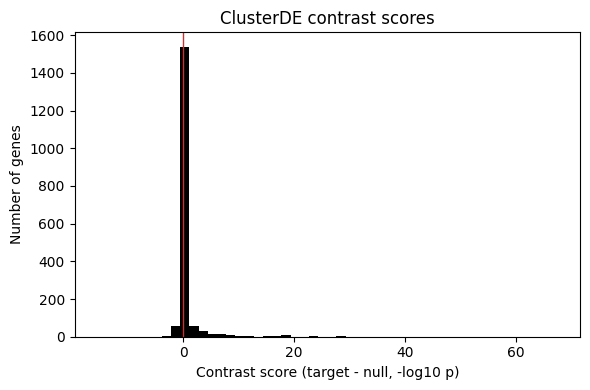

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(result["contrast_score"], bins=50, color="black")
ax.axvline(0, color="#C73333", linewidth=1)
ax.set_xlabel("Contrast score (target - null, -log10 p)")
ax.set_ylabel("Number of genes")
ax.set_title(f"ClusterDE contrast scores")
fig.tight_layout()
fig.show()